In [47]:
import cv2
import keras
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, concatenate, BatchNormalization, SpatialDropout2D, Activation, Flatten
from keras.models import Model

import tensorflow as tf
from tensorflow.keras import layers, regularizers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import medmnist
from medmnist import OrganCMNIST

In [4]:
train = OrganCMNIST(split = "train", download = True, size = 128)
val = OrganCMNIST(split = "val", download = True, size = 128)
test = OrganCMNIST(split = "test", download = True, size = 128)

In [35]:
train_X = train.imgs
train_Y = train.labels

val_X = val.imgs 
val_Y = val.labels

test_X = test.imgs
test_Y = test.labels


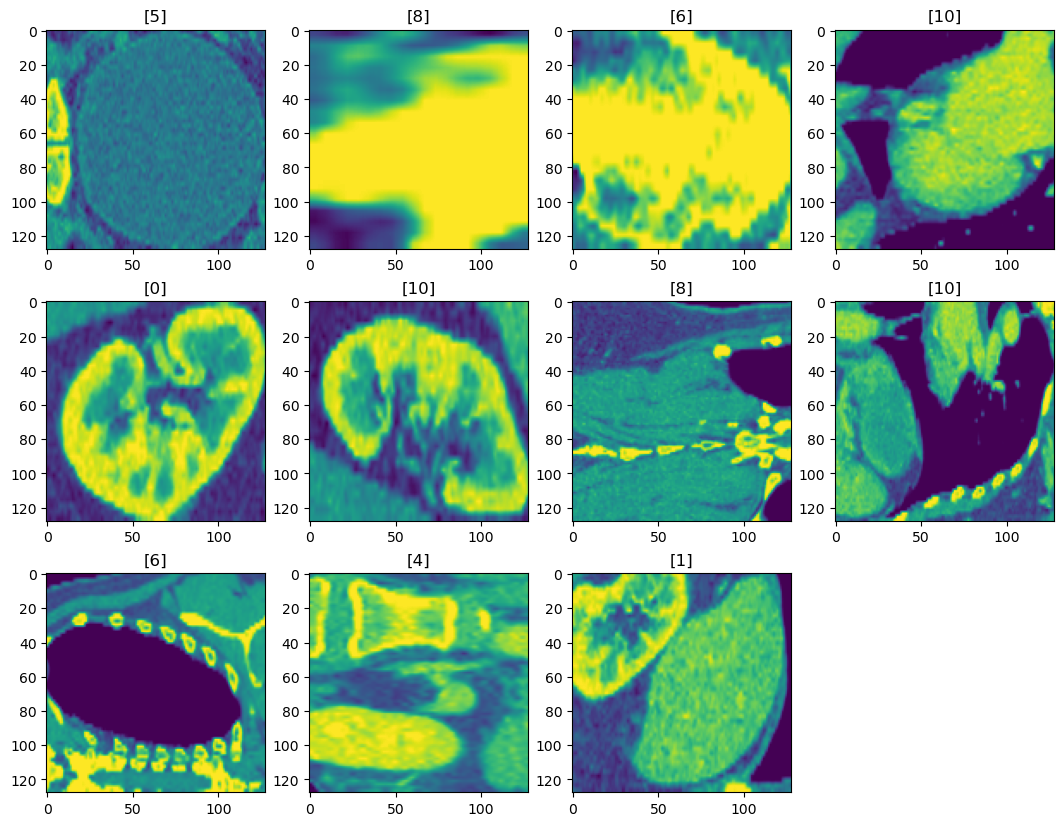

In [43]:
# idk wtf im looking at so like... find it
np.unique(train_Y)
unique_obj = []
for i in range(11):
    index = np.where(train_Y == i)[0][0]
    unique_obj.append(index)

unique_imgs = train_X[unique_obj]

fig = plt.figure(figsize = [13,10])
for i in range(11):
    ax = fig.add_subplot(3,4,i+1)
    ax.imshow(unique_imgs[i])
    ax.set_title(train_Y[i])

In [45]:
backbone = keras.applications.InceptionV3(
                    include_top=False,
                    input_shape=(128,128,3),
                    pooling = "max",
                    name="inception_v3"
                )

In [59]:
train_X = np.stack([train_X] * 3, axis=-1)
val_X = np.stack([val_X] * 3, axis=-1)
test_X = np.stack([test_X] * 3, axis=-1)

In [60]:
train_X.shape

(12975, 128, 128, 3)

In [61]:
train_X = keras.applications.inception_v3.preprocess_input(train_X, data_format=None)
val_X = keras.applications.inception_v3.preprocess_input(val_X, data_format=None)
test_X = keras.applications.inception_v3.preprocess_input(test_X, data_format=None)

In [44]:
backbone.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 63, 63,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 63, 63,    │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 63, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 61, 61,    │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 61, 61,    │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 30, 30,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 30, 30,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 30,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 30, 30,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 28, 28,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [55]:
x = backbone.output

x = Dense(128, activation = "relu")(x)
x = layers.Dropout(0.4)(x)
classifier = Dense(11, activation = "softmax", name = 'classifier')(x)

model = keras.Model(inputs = backbone.inputs, outputs = classifier, name = "final_model")


In [56]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)


In [58]:
train_X.shape

(12975, 128, 128)

In [ ]:
model.compile(optimizer = keras.optimizers.AdamW(), 
                      loss = keras.losses.CategoricalFocalCrossentropy(gamma = 2.0),
                      metrics = ['categorical_accuracy'])

epochs = 20
history = model.fit(train_X, train_Y, epochs=epochs, batch_size = 64,
                       validation_data = [val_X, val_Y], callbacks=[early_stop])

Epoch 1/20
 11/203 ━━━━━━━━━━━━━━━━━━━━ 7:45 2s/step - categorical_accuracy: 0.1065 - loss: 34.9725